In [4]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from huggingface_hub import InferenceClient

e:\repo\langG\langG\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
load_dotenv()

True

In [6]:
# LLM Model
import os
client = InferenceClient(
    api_key=os.environ['HF_TOKEN'],
)


def invoke_model(message, model="openai/gpt-oss-20b:groq"):
    completion = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "user", "content": message}
        ],
    )
    return completion.choices[0].message["content"]

In [14]:
# Pydantic Schema Prepration 
class SentimentSchema(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description= 'sentiment of the review')


In [25]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support","Other"] = Field(description="Category of issue mentioned in review")
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description="The emotional tone expressed by the user")
    urgency: Literal["low", "medium", "high"] = Field(description="How urgentor critical the isuue appear to be")

In [8]:
text=" The software is too bad.. "

In [9]:
prompt = f"""
What is the sentiment of the given text:

Respond ONLY in valid JSON.
Do NOT include explanations, markdown, or extra text.

Format:
{{
  
  "sentiment": positive or negative
}}

text:
{text}
"""

In [11]:
response = invoke_model(prompt)

print(response)



{
  "sentiment": "negative"
}


In [15]:
# Convert to structured output
result = SentimentSchema.model_validate_json(response)

print(result)

sentiment='negative'


In [17]:
class ReviewState(TypedDict):
    
    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis:dict
    response: str


In [60]:
def  find_sentiment(state: ReviewState):

    prompt = f"""
    What is the sentiment of the given text:

    Respond ONLY in valid JSON.
    Do NOT include explanations, markdown, or extra text.

    Format:
    {{
    
    "sentiment": positive or negative
    }}

    text:
    {state["review"]}
    """
    response = invoke_model(prompt)
    result = SentimentSchema.model_validate_json(response).sentiment

    return {'sentiment': result}

def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:
    if state["sentiment"] == 'positive':
        return 'positive_response'
    else:
        return "run_diagnosis"

def positive_response(state: ReviewState):
    prompt= f""" Write a warm thank-you message in 10 words in response to this review:
     \n\n\"{state['review']}\"\n
     Also, kindly ask the user to leave feedback on our website.
    """
    response = invoke_model(prompt)
    return {'response': response}


def run_diagnosis(state: ReviewState):

    prompt = f"""
    Diagnose the neagtive rview:

    Respond ONLY in valid JSON.
    Do NOT include explanations, markdown, or extra text.

    Format:
    {{
    
    "issue_type": "UX", "Performance", "Bug", "Support","Other"
    "tone": "angry", "frustrated", "disappointed", "calm"
    "urgency": "low", "medium", "high"
    }}

    text:
    {state["review"]}
    """
    response = invoke_model(prompt)
    result = DiagnosisSchema.model_validate_json(response)
    print( result)
    return {"diagnosis": {'issue_type': result.issue_type, 'tone': result.tone, 'urgency': result.urgency}}

def neagtive_response(state: ReviewState):
    diagnosis= state['diagnosis']
    
    prompt=f""" You are asupport assitant
    The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}' as  '{diagnosis['urgency']}'. 
    Write an empathetic, helpful resolution message.
    """

    response = invoke_model(prompt)
    return {'response': response}





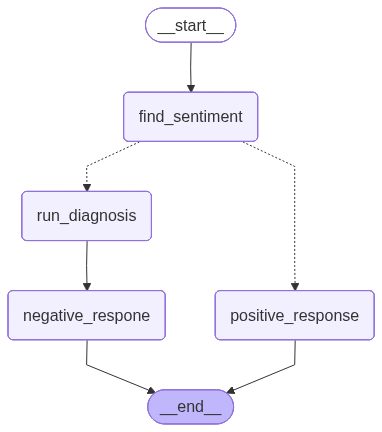

In [61]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_respone', neagtive_response)

graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment )
graph.add_edge('positive_response', END)
graph.add_edge('run_diagnosis', 'negative_respone')
graph.add_edge('negative_respone', END)

workflow=graph.compile()
workflow

In [62]:
initial_state={"review": "The software is too bad in visualization .."}

workflow.invoke(initial_state)

issue_type='UX' tone='disappointed' urgency='low'


{'review': 'The software is too bad in visualization ..',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'UX', 'tone': 'disappointed', 'urgency': 'low'},
 'response': 'I’m really sorry you’re having a frustrating experience. It sounds like the layout you’re seeing isn’t working the way it should, and that’s understandably disappointing—especially when you’re trying to get things done efficiently.\n\n**Here’s what I can do right now to help:**\n\n1. **Re‑create the issue**  \n   - Could you let me know the exact steps you’re taking when the problem shows up?  \n   - If possible, a short screenshot or a quick screen recording (you can use the built‑in Windows/Mac recorder or a free app like Loom) will help me see exactly what you’re experiencing.\n\n2. **Immediate Work‑around**  \n   - If the problem is related to a specific page or feature, you might try clearing your browser cache or switching to a different browser (Chrome, Firefox, Safari).  \n   - For mobile, a quick restart